In [3]:
# Core imports
import os, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# NLP
import re, string
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.pipeline import Pipeline

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Embedding, Conv1D,
    GlobalMaxPooling1D, Input, Flatten, BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import scipy.sparse as sp

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Connect to Drive
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/ai_human_detection_project/notebooks')
DATA_PATH = '../data/training_data/train_data_with_labels.xlsx'
MODELS_DIR = '../models'

print('Successfully imported all libraries.')

Successfully imported all libraries.


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/rupakkadel/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/rupakkadel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/rupakkadel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


# Section I: Data Exploration & Preprocessing

In [5]:
# Read input file
df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
print(df.head(10))

Shape: (8176, 2)
                                                text  label
0  Councils are debating if building housing area...      0
1  While reading the succesful people's lifes you...      0
2  Finally, she felt that the robotics unit was i...      1
3  Since sigmoid can be viewed as a special 2clas...      1
4  In this essay we will talk about why in so man...      0
5  Evaluation of the importance of timing is esse...      0
6  I disagree because I don‚Äôt think it‚Äôs impo...      1
7  The Code.org Advanced Placement Computer Scien...      0
8  There are several countries that are economica...      1
9  Due to the non-random nature of the survey sam...      0


In [6]:
df.describe()

,label
count,8176.000000
mean,0.500000
std,0.500031
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


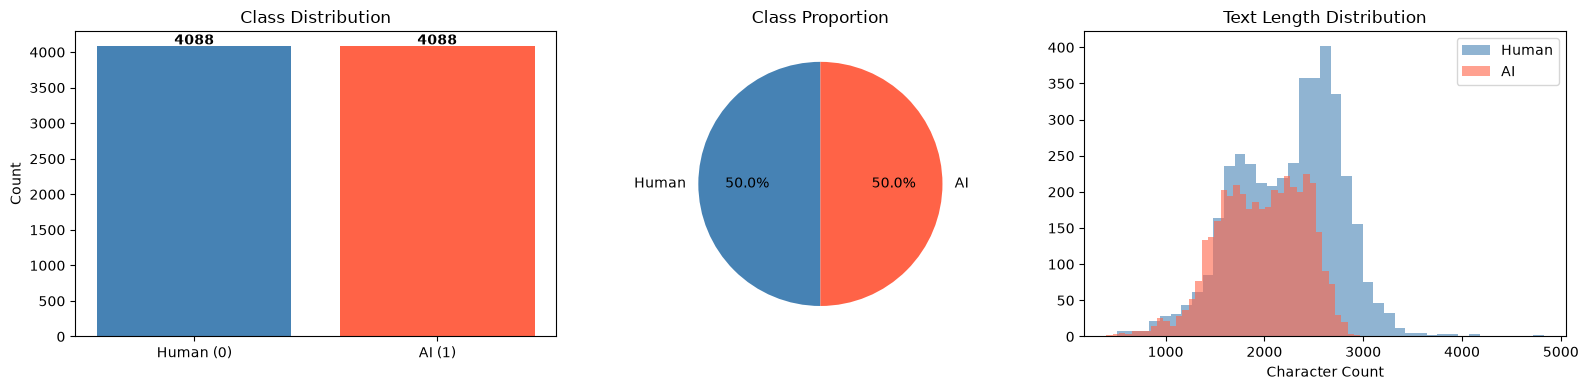

Label counts:
 label
0    4088
1    4088
Name: count, dtype: int64


In [7]:
# Data visualization and check class balance

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
counts = df['label'].value_counts()
axes[0].bar(['Human (0)', 'AI (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Human', 'AI'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion')

# Text length distribution
df['text_length'] = df['text'].str.len()
for lbl, color, name in [(0, 'steelblue', 'Human'), (1, 'tomato', 'AI')]:
    axes[2].hist(df[df['label']==lbl]['text_length'], bins=40,
                 alpha=0.6, color=color, label=name)
axes[2].set_title('Text Length Distribution')
axes[2].set_xlabel('Character Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=120)
plt.show()
print('Label counts:\n', counts)

In [8]:
# Text Preprocessing
stop_words = set(stopwords.words('english') + ['u', 'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure', 'et', 'al', 'fig', 'eq'])

def text_process(text):
    # Handle non-string values
    if not isinstance(text, str):
        return ""

    # Remove standalone numbers
    text = re.sub(r'\b\d+\b', '', text)

    # Remove punctuation
    nopunc = ''.join([char for char in text if char not in string.punctuation])

    # Remove stopwords
    return ' '.join([word for word in nopunc.split() if word.lower() not in stop_words])

In [9]:
# Apply the function to the dataframe column
df['clean_text'] = df['text'].apply(text_process)
df.head()

,text,label,text_length,clean_text
0,Councils are debating if building housing area...,0,1778,Councils debating building housing areas expan...
1,While reading the succesful people's lifes you...,0,1724,reading succesful peoples lifes probably see o...
2,"Finally, she felt that the robotics unit was i...",1,2325,Finally felt robotics unit important engage st...
3,Since sigmoid can be viewed as a special 2clas...,1,1983,Since sigmoid viewed special 2class case E cas...
4,In this essay we will talk about why in so man...,0,1604,essay talk many countries students prefer choo...


In [10]:
from collections import Counter

# Tokenize each text by splitting on whitespace
tokenized_texts = df['clean_text'].apply(lambda text: text.split())

# Flatten the list of token lists into a single list of tokens
all_tokens = [word for tokens in tokenized_texts for word in tokens]

# Count the frequency of each token
token_counter = Counter(all_tokens)

# Display the 50 most common tokens
print(token_counter.most_common(50))

[('new', 9378), ('people', 8741), ('model', 7284), ('students', 5769), ('data', 5186), ('things', 5143), ('risks', 4935), ('successful', 4788), ('models', 4584), ('also', 4360), ('take', 4253), ('one', 4204), ('two', 3920), ('learning', 3752), ('work', 3721), ('performance', 3418), ('try', 3394), ('success', 3385), ('example', 3267), ('may', 3242), ('using', 3241), ('training', 3241), ('within', 3140), ('language', 3132), ('set', 2995), ('information', 2986), ('time', 2932), ('use', 2875), ('different', 2856), ('approach', 2818), ('many', 2777), ('specific', 2768), ('dataset', 2700), ('word', 2697), ('life', 2697), ('would', 2666), ('results', 2658), ('study', 2632), ('task', 2619), ('However', 2608), ('well', 2522), ('tasks', 2512), ('often', 2453), ('know', 2445), ('used', 2430), ('knowledge', 2390), ('text', 2384), ('across', 2335), ('analysis', 2301), ('risk', 2283)]


In [11]:
# Word frequency — BEFORE lemmatization (on clean_text)
from collections import Counter

tokenized_texts = df['clean_text'].apply(lambda text: text.split())
all_tokens = [word for tokens in tokenized_texts for word in tokens]
token_counter_before = Counter(all_tokens)

print("Vocabulary size before lemmatization:", len(token_counter_before))
print("\nTop 50 tokens (before lemmatization):")
print(token_counter_before.most_common(50))

Vocabulary size before lemmatization: 66967

Top 50 tokens (before lemmatization):
[('new', 9378), ('people', 8741), ('model', 7284), ('students', 5769), ('data', 5186), ('things', 5143), ('risks', 4935), ('successful', 4788), ('models', 4584), ('also', 4360), ('take', 4253), ('one', 4204), ('two', 3920), ('learning', 3752), ('work', 3721), ('performance', 3418), ('try', 3394), ('success', 3385), ('example', 3267), ('may', 3242), ('using', 3241), ('training', 3241), ('within', 3140), ('language', 3132), ('set', 2995), ('information', 2986), ('time', 2932), ('use', 2875), ('different', 2856), ('approach', 2818), ('many', 2777), ('specific', 2768), ('dataset', 2700), ('word', 2697), ('life', 2697), ('would', 2666), ('results', 2658), ('study', 2632), ('task', 2619), ('However', 2608), ('well', 2522), ('tasks', 2512), ('often', 2453), ('know', 2445), ('used', 2430), ('knowledge', 2390), ('text', 2384), ('across', 2335), ('analysis', 2301), ('risk', 2283)]


In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(text):
    tokens = text.split()
    pos_tags = nltk.pos_tag(tokens)
    return " ".join(
        lemmatizer.lemmatize(token, get_wordnet_pos(pos))
        for token, pos in pos_tags
    )

df['lemmatized_text'] = df['clean_text'].apply(lemmatize_text)
df[['clean_text', 'lemmatized_text']].head()

In [ ]:
# Word frequency — AFTER lemmatization
tokenized_texts_lemma = df['lemmatized_text'].apply(lambda text: text.split())
all_tokens_lemma = [word for tokens in tokenized_texts_lemma for word in tokens]
token_counter_after = Counter(all_tokens_lemma)

print("Vocabulary size after lemmatization:", len(token_counter_after))
print(f"Vocabulary reduction: {len(token_counter_before) - len(token_counter_after)} "
      f"unique tokens merged ({(1 - len(token_counter_after)/len(token_counter_before))*100:.1f}%)")
print("\nTop 50 tokens (after lemmatization):")
print(token_counter_after.most_common(50))

Vocabulary size after lemmatization: 62698
Vocabulary reduction: 4269 unique tokens merged (6.4%)

Top 50 tokens (after lemmatization):
[('model', 12595), ('new', 9416), ('people', 8859), ('use', 8757), ('student', 7647), ('take', 7378), ('risk', 7256), ('thing', 6023), ('try', 5313), ('learn', 5201), ('task', 5200), ('data', 5187), ('work', 5178), ('successful', 4788), ('word', 4786), ('one', 4726), ('also', 4360), ('result', 4346), ('example', 4291), ('approach', 4223), ('set', 4058), ('make', 3974), ('two', 3920), ('study', 3881), ('sentence', 3827), ('language', 3791), ('time', 3596), ('well', 3575), ('performance', 3469), ('success', 3424), ('train', 3392), ('system', 3375), ('method', 3348), ('know', 3319), ('may', 3242), ('within', 3140), ('life', 3049), ('information', 3005), ('propose', 2980), ('score', 2882), ('provide', 2875), ('different', 2856), ('representation', 2840), ('follow', 2831), ('question', 2804), ('specific', 2786), ('many', 2777), ('dataset', 2700), ('high', 2

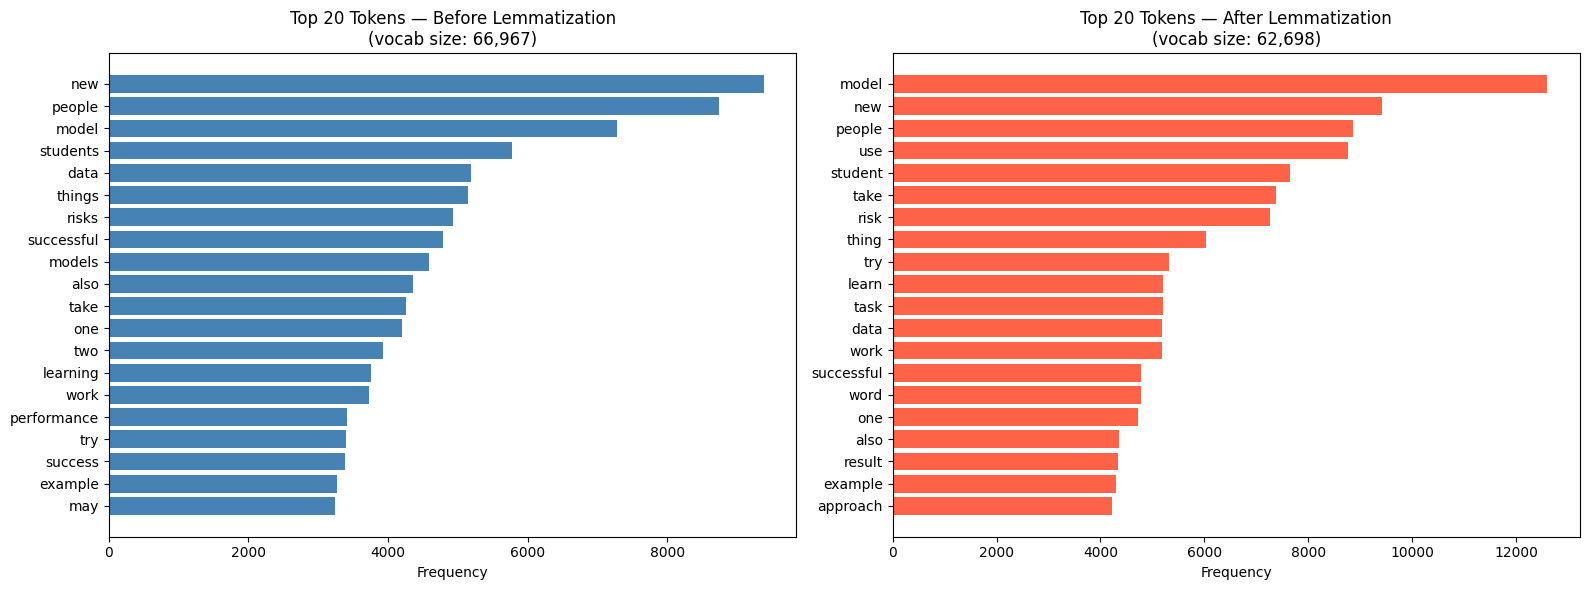

In [ ]:
# Before vs After Lemmatization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_before = token_counter_before.most_common(20)
axes[0].barh([w for w, _ in top_before[::-1]], [c for _, c in top_before[::-1]], color='steelblue')
axes[0].set_title(f'Top 20 Tokens — Before Lemmatization\n(vocab size: {len(token_counter_before):,})')
axes[0].set_xlabel('Frequency')

top_after = token_counter_after.most_common(20)
axes[1].barh([w for w, _ in top_after[::-1]], [c for _, c in top_after[::-1]], color='tomato')
axes[1].set_title(f'Top 20 Tokens — After Lemmatization\n(vocab size: {len(token_counter_after):,})')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../data/lemmatization_comparison.png', dpi=120)
plt.show()

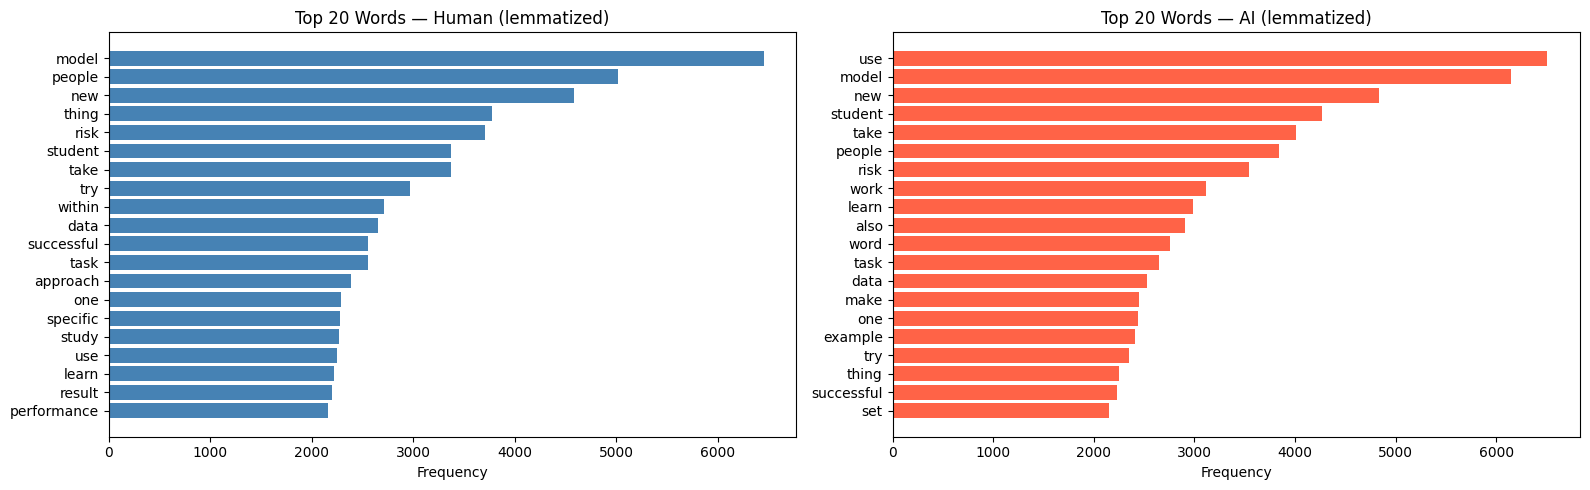

In [ ]:
# Word frequency Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, lbl, color, name in zip(axes, [0, 1], ['steelblue', 'tomato'], ['Human', 'AI']):
    words = ' '.join(df[df['label']==lbl]['lemmatized_text']).split()
    common = Counter(words).most_common(20)
    ax.barh([w for w, _ in common[::-1]], [c for _, c in common[::-1]], color=color)
    ax.set_title(f'Top 20 Words — {name} (lemmatized)')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../data/word_frequency_by_class.png', dpi=120)
plt.show()

In [ ]:
# Train / test split
X_raw   = df['text'].to_numpy()
X_clean = df['clean_text'].to_numpy()
X_lemma = df['lemmatized_text'].to_numpy()
y       = df['label'].to_numpy()

X_raw_train, X_raw_test, X_clean_train, X_clean_test, X_lemma_train, X_lemma_test, y_train, y_test = train_test_split(
    X_raw, X_clean, X_lemma, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Train label balance: {np.bincount(y_train)}')
print(f'Test  label balance: {np.bincount(y_test)}')

# Section II: Feature Engineering

In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=3)
X_tfidf_train = tfidf.fit_transform(X_lemma_train)
X_tfidf_test  = tfidf.transform(X_lemma_test)

pickle.dump(tfidf, open(f'{MODELS_DIR}/tfidf_vectorizer.pkl', 'wb'))
print('TF-IDF train shape:', X_tfidf_train.shape)

In [ ]:
# Word Embeddings — GloVe
GLOVE_PATH = '../data/glove.6B.100d.txt'

def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            embeddings[parts[0]] = np.array(parts[1:], dtype=np.float32)
    return embeddings

def text_to_glove(text, embeddings, dim=100):
    tokens = text.split()
    vecs = [embeddings[t] for t in tokens if t in embeddings]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

if os.path.exists(GLOVE_PATH):
    print('Loading GloVe embeddings...')
    glove = load_glove(GLOVE_PATH)
    X_glove_train = np.array([text_to_glove(t, glove) for t in X_clean_train])
    X_glove_test  = np.array([text_to_glove(t, glove) for t in X_clean_test])
    GLOVE_AVAILABLE = True
    print('GloVe train shape:', X_glove_train.shape)
else:
    print('GloVe file not found — using TF-IDF dense fallback for embedding features.')
    from sklearn.decomposition import TruncatedSVD
    svd = TruncatedSVD(n_components=100, random_state=SEED)
    X_glove_train = svd.fit_transform(X_tfidf_train)
    X_glove_test  = svd.transform(X_tfidf_test)
    GLOVE_AVAILABLE = False
    print('LSA (TF-IDF SVD) train shape:', X_glove_train.shape)

Loading GloVe embeddings...
GloVe train shape: (6540, 100)


In [ ]:
# Linguistic Features
from collections import Counter

def linguistic_features(text):
    """15 hand-crafted stylometric signals."""
    sentences = sent_tokenize(text)
    words     = word_tokenize(text.lower())
    words_alpha = [w for w in words if w.isalpha()]
    n_words   = max(len(words_alpha), 1)
    n_sents   = max(len(sentences), 1)
    n_chars   = max(len(text), 1)

    avg_sent_len    = n_words / n_sents
    avg_word_len    = np.mean([len(w) for w in words_alpha]) if words_alpha else 0
    vocab_richness  = len(set(words_alpha)) / n_words          # TTR
    punct_density   = sum(1 for c in text if c in string.punctuation) / n_chars
    comma_rate      = text.count(',') / n_sents
    semicolon_rate  = text.count(';') / n_sents
    question_rate   = text.count('?') / n_sents
    exclaim_rate    = text.count('!') / n_sents
    paragraph_count = text.count('\n') + 1
    long_word_ratio = sum(1 for w in words_alpha if len(w) > 7) / n_words
    uppercase_ratio = sum(1 for c in text if c.isupper()) / n_chars
    # Flesch Reading Ease approximation
    syllables = sum(max(1, len(re.findall(r'[aeiou]', w, re.I))) for w in words_alpha)
    flesch = 206.835 - 1.015*(n_words/n_sents) - 84.6*(syllables/n_words)
    # Hapax legomena ratio
    freq = Counter(words_alpha)
    hapax_ratio = sum(1 for v in freq.values() if v == 1) / n_words
    # Avg chars per sentence
    avg_sent_chars = n_chars / n_sents

    return [
        avg_sent_len, avg_word_len, vocab_richness, punct_density,
        comma_rate, semicolon_rate, question_rate, exclaim_rate,
        paragraph_count, long_word_ratio, uppercase_ratio,
        flesch, hapax_ratio, avg_sent_chars, n_words
    ]

print('Computing linguistic features...')
X_ling_train = np.array([linguistic_features(t) for t in X_raw_train])
X_ling_test  = np.array([linguistic_features(t) for t in X_raw_test])

scaler = StandardScaler()
X_ling_train = scaler.fit_transform(X_ling_train)
X_ling_test  = scaler.transform(X_ling_test)
pickle.dump(scaler, open(f'{MODELS_DIR}/ling_scaler.pkl', 'wb'))

print('Linguistic train shape:', X_ling_train.shape)

In [ ]:
# Feature comparison
from sklearn.svm import LinearSVC

rep_results = {}

for name, Xtr, Xte in [
    ('TF-IDF',      X_tfidf_train, X_tfidf_test),
    ('GloVe/LSA',   X_glove_train, X_glove_test),
    ('Linguistic',  X_ling_train,  X_ling_test),
]:
    clf = LinearSVC(max_iter=3000, random_state=SEED)
    clf.fit(Xtr, y_train)
    acc = accuracy_score(y_test, clf.predict(Xte))
    f1  = f1_score(y_test, clf.predict(Xte), average='macro')
    rep_results[name] = {'accuracy': acc, 'f1': f1}
    print(f'{name:15s}  acc={acc:.4f}  f1={f1:.4f}')

# Combine TF-IDF + Linguistic
X_combo_train = sp.hstack([X_tfidf_train, sp.csr_matrix(X_ling_train)])
X_combo_test  = sp.hstack([X_tfidf_test,  sp.csr_matrix(X_ling_test)])
clf = LinearSVC(max_iter=3000, random_state=SEED)
clf.fit(X_combo_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_combo_test))
f1  = f1_score(y_test, clf.predict(X_combo_test), average='macro')
rep_results['TF-IDF+Ling'] = {'accuracy': acc, 'f1': f1}
print(f'{"TF-IDF+Ling":15s}  acc={acc:.4f}  f1={f1:.4f}')

TF-IDF           acc=0.9774  f1=0.9774
GloVe/LSA        acc=0.7842  f1=0.7842
Linguistic       acc=0.8117  f1=0.8115
TF-IDF+Ling      acc=0.9786  f1=0.9786


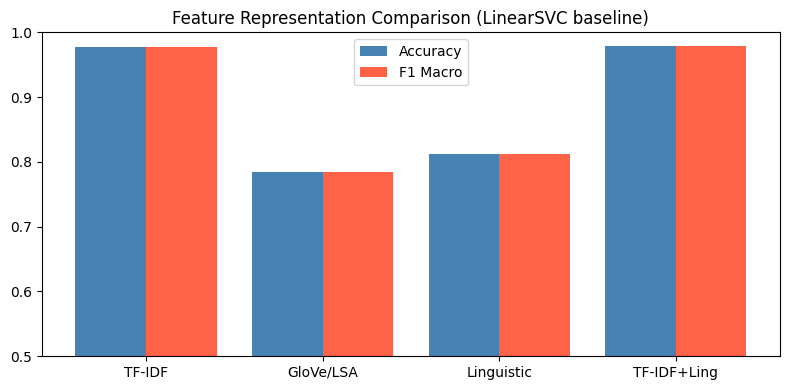

In [ ]:
# Visualise feature comparison
fig, ax = plt.subplots(figsize=(8, 4))
names = list(rep_results.keys())
accs  = [rep_results[n]['accuracy'] for n in names]
f1s   = [rep_results[n]['f1']       for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, accs, 0.4, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, f1s,  0.4, label='F1 Macro', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.5, 1.0)
ax.set_title('Feature Representation Comparison (LinearSVC baseline)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/feature_comparison.png', dpi=120)
plt.show()

# Section III: Model Training and Tuning

In [ ]:
results = {}

def store_results(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    results[name] = dict(acc=acc, prec=prec, rec=rec, f1=f1,
                         roc_auc=roc_auc, fpr=fpr, tpr=tpr,
                         y_pred=y_pred, y_prob=y_prob)
    print(f'{name:30s}  acc={acc:.4f}  f1={f1:.4f}  AUC={roc_auc:.4f}')
    return results[name]

In [ ]:
# SVM
print('Training SVM...')
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_cv = GridSearchCV(SVC(probability=True, random_state=SEED),
                      svm_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
svm_cv.fit(X_tfidf_train, y_train)
best_svm = svm_cv.best_estimator_
print('Best SVM params:', svm_cv.best_params_)

y_pred_svm  = best_svm.predict(X_tfidf_test)
y_prob_svm  = best_svm.predict_proba(X_tfidf_test)[:, 1]
store_results('SVM', y_test, y_pred_svm, y_prob_svm)
pickle.dump(best_svm, open(f'{MODELS_DIR}/svm_model.pkl', 'wb'))
print('SVM saved')

Training SVM...
Best SVM params: {'C': 10, 'kernel': 'linear'}
SVM                             acc=0.9749  f1=0.9749  AUC=0.9965
SVM saved ✓


In [ ]:
# Decision Tree
print('Training Decision Tree...')
dt_param_grid = {'max_depth': [10, 20, 30, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}
dt_cv = RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED),
                           dt_param_grid, n_iter=12, cv=3,
                           scoring='f1', random_state=SEED, n_jobs=-1)
dt_cv.fit(X_tfidf_train, y_train)
best_dt = dt_cv.best_estimator_
print('Best DT params:', dt_cv.best_params_)

y_pred_dt = best_dt.predict(X_tfidf_test)
y_prob_dt = best_dt.predict_proba(X_tfidf_test)[:, 1]
store_results('Decision Tree', y_test, y_pred_dt, y_prob_dt)
pickle.dump(best_dt, open(f'{MODELS_DIR}/decision_tree_model.pkl', 'wb'))
print('Decision Tree saved')

Training Decision Tree...
Best DT params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Decision Tree                   acc=0.9071  f1=0.9067  AUC=0.9119
Decision Tree saved ✓


In [ ]:
# AdaBoost
print('Training AdaBoost...')
ada_param_grid = {'n_estimators': [50, 100, 200],
                  'learning_rate': [0.5, 1.0, 1.5]}
ada_cv = GridSearchCV(AdaBoostClassifier(random_state=SEED),
                      ada_param_grid, cv=3, scoring='f1', n_jobs=-1)
ada_cv.fit(X_tfidf_train, y_train)
best_ada = ada_cv.best_estimator_
print('Best AdaBoost params:', ada_cv.best_params_)

y_pred_ada = best_ada.predict(X_tfidf_test)
y_prob_ada = best_ada.predict_proba(X_tfidf_test)[:, 1]
store_results('AdaBoost', y_test, y_pred_ada, y_prob_ada)
pickle.dump(best_ada, open(f'{MODELS_DIR}/adaboost_model.pkl', 'wb'))
print('AdaBoost saved')

Training AdaBoost...
Best AdaBoost params: {'learning_rate': 1.5, 'n_estimators': 200}
AdaBoost                        acc=0.9621  f1=0.9623  AUC=0.9921
AdaBoost saved ✓


In [ ]:
# Deep Learning shared setup
MAX_WORDS  = 15_000
MAX_LEN    = 300
EMBED_DIM  = 128
BATCH_SIZE = 64
EPOCHS     = 20

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_raw_train)

def to_sequences(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_seq_train = to_sequences(X_raw_train)
X_seq_test  = to_sequences(X_raw_test)
print('Sequence train shape:', X_seq_train.shape)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Also save tokenizer
pickle.dump(tokenizer, open(f'{MODELS_DIR}/tokenizer.pkl', 'wb'))

Sequence train shape: (6540, 300)


In [ ]:
# Feedforward Neural Network (FNN) — on TF-IDF dense
print('Training FNN...')

# Convert sparse TF-IDF to dense for FNN
X_dense_train = X_tfidf_train.toarray().astype(np.float32)
X_dense_test  = X_tfidf_test.toarray().astype(np.float32)

fnn = Sequential([
    Input(shape=(X_dense_train.shape[1],)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='FNN')

fnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
fnn.summary()

history_fnn = fnn.fit(
    X_dense_train, y_train,
    validation_split=0.15, batch_size=BATCH_SIZE,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)
fnn.save(f'{MODELS_DIR}/fnn_model.h5')

y_prob_fnn = fnn.predict(X_dense_test, verbose=0).flatten()
y_pred_fnn = (y_prob_fnn > 0.5).astype(int)
store_results('FNN', y_test, y_pred_fnn, y_prob_fnn)
print('FNN saved')

Training FNN...


Model: "FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,287,937 (20.17 MB)

 Trainable params: 5,286,401 (20.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.9090 - loss: 0.2079 - val_accuracy: 0.9072 - val_loss: 0.5503 - learning_rate: 0.0010
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.9924 - loss: 0.0270 - val_accuracy: 0.9796 - val_loss: 0.3530 - learning_rate: 0.0010
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9987 - loss: 0.0059 - val_accuracy: 0.9694 - val_loss: 0.2070 - learning_rate: 0.0010
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9776 - val_loss: 0.1080 - learning_rate: 0.0010
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9991 - loss: 0.0053 - val_accuracy: 0.9766 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9786 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 1.0000 - loss: 7.3939e-04

FNN                             acc=0.9762  f1=0.9760  AUC=0.9964
FNN saved ✓


In [ ]:
# LSTM
print('Training LSTM...')

lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
    LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='LSTM')

lstm_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_seq_train, y_train,
    validation_split=0.15, batch_size=BATCH_SIZE,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)
lstm_model.save(f'{MODELS_DIR}/lstm_model.h5')

y_prob_lstm = lstm_model.predict(X_seq_test, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
store_results('LSTM', y_test, y_pred_lstm, y_prob_lstm)
print('LSTM saved')

Training LSTM...


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.7187 - loss: 0.5720 - val_accuracy: 0.8654 - val_loss: 0.3836 - learning_rate: 0.0010
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8021 - loss: 0.4905 - val_accuracy: 0.9093 - val_loss: 0.3159 - learning_rate: 0.0010
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9115 - loss: 0.2724 - val_accuracy: 0.8869 - val_loss: 0.3024 - learning_rate: 5.0000e-04


LSTM                            acc=0.8515  f1=0.8388  AUC=0.9184
LSTM saved ✓


In [ ]:
# CNN for Text
print('Training CNN...')

# Multi-filter CNN (3, 4, 5 gram convolutions)
inp = Input(shape=(MAX_LEN,))
emb = Embedding(MAX_WORDS, EMBED_DIM)(inp)

branches = []
for fsize in [3, 4, 5]:
    conv = Conv1D(128, fsize, activation='relu')(emb)
    pool = GlobalMaxPooling1D()(conv)
    branches.append(pool)

merged = keras.layers.concatenate(branches)
drop   = Dropout(0.4)(merged)
dense  = Dense(128, activation='relu')(drop)
drop2  = Dropout(0.3)(dense)
out    = Dense(1, activation='sigmoid')(drop2)

cnn_model = Model(inputs=inp, outputs=out, name='TextCNN')
cnn_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_seq_train, y_train,
    validation_split=0.15, batch_size=BATCH_SIZE,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)
cnn_model.save(f'{MODELS_DIR}/cnn_model.h5')

y_prob_cnn = cnn_model.predict(X_seq_test, verbose=0).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)
store_results('CNN', y_test, y_pred_cnn, y_prob_cnn)
print('CNN saved')

Training CNN...


Model: "TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  1,920,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 298, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 297, 128)  │     65,664 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 296, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     49,280 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,166,401 (8.26 MB)

 Trainable params: 2,166,401 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 69s 743ms/step - accuracy: 0.6834 - loss: 0.5639 - val_accuracy: 0.8950 - val_loss: 0.2561 - learning_rate: 0.0010
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 70s 610ms/step - accuracy: 0.9304 - loss: 0.1770 - val_accuracy: 0.9633 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 80s 587ms/step - accuracy: 0.9775 - loss: 0.0691 - val_accuracy: 0.9684 - val_loss: 0.0839 - learning_rate: 5.0000e-04


CNN                             acc=0.8985  f1=0.9038  AUC=0.9657
CNN saved ✓


# Section IV: Evaluation

In [ ]:
# Summary table
summary = pd.DataFrame([
    {'Model': k,
     'Accuracy':  round(v['acc'],  4),
     'Precision': round(v['prec'], 4),
     'Recall':    round(v['rec'],  4),
     'F1':        round(v['f1'],   4),
     'ROC AUC':   round(v['roc_auc'], 4)}
    for k, v in results.items()
]).sort_values('F1', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))
summary.to_csv('../data/model_comparison.csv', index=False)

        Model  Accuracy  Precision  Recall     F1  ROC AUC
          FNN    0.9762     0.9827  0.9694 0.9760   0.9964
          SVM    0.9749     0.9755  0.9743 0.9749   0.9965
     AdaBoost    0.9621     0.9565  0.9682 0.9623   0.9921
Decision Tree    0.9071     0.9101  0.9034 0.9067   0.9119
          CNN    0.8985     0.8590  0.9535 0.9038   0.9657
         LSTM    0.8515     0.9173  0.7726 0.8388   0.9184


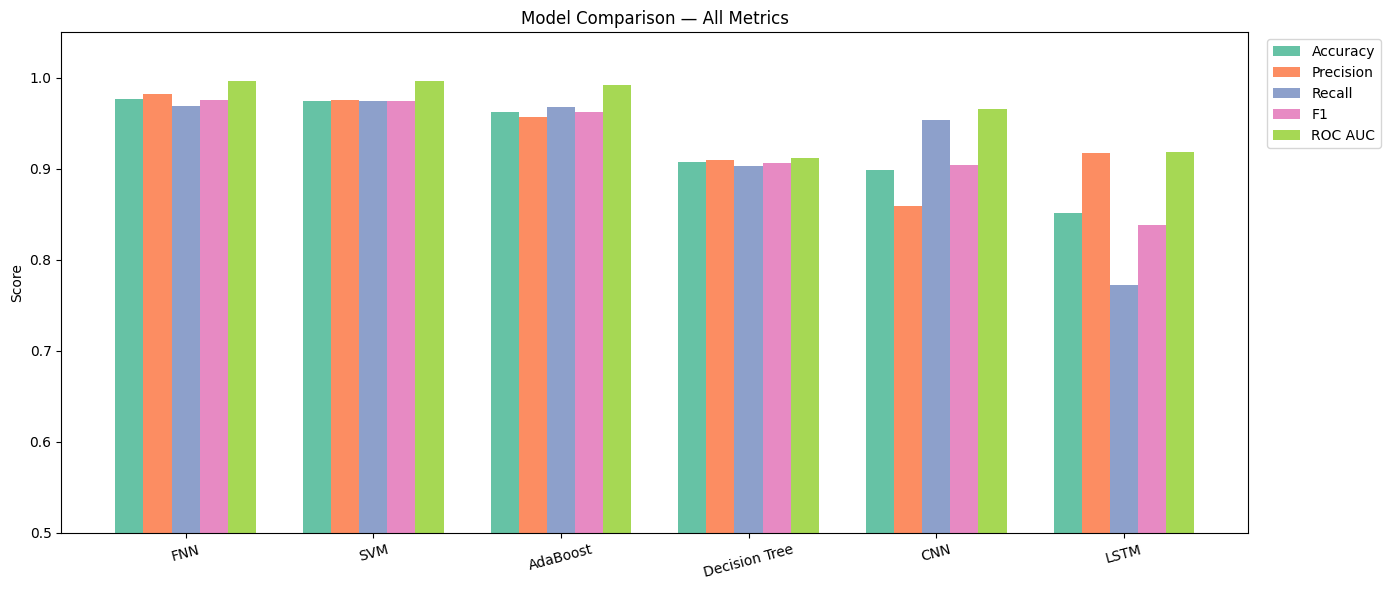

In [ ]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
x = np.arange(len(summary))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.Set2.colors
for i, m in enumerate(metrics):
    ax.bar(x + i*width, summary[m], width, label=m, color=colors[i])

ax.set_xticks(x + width*2)
ax.set_xticklabels(summary['Model'], rotation=15)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison — All Metrics')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

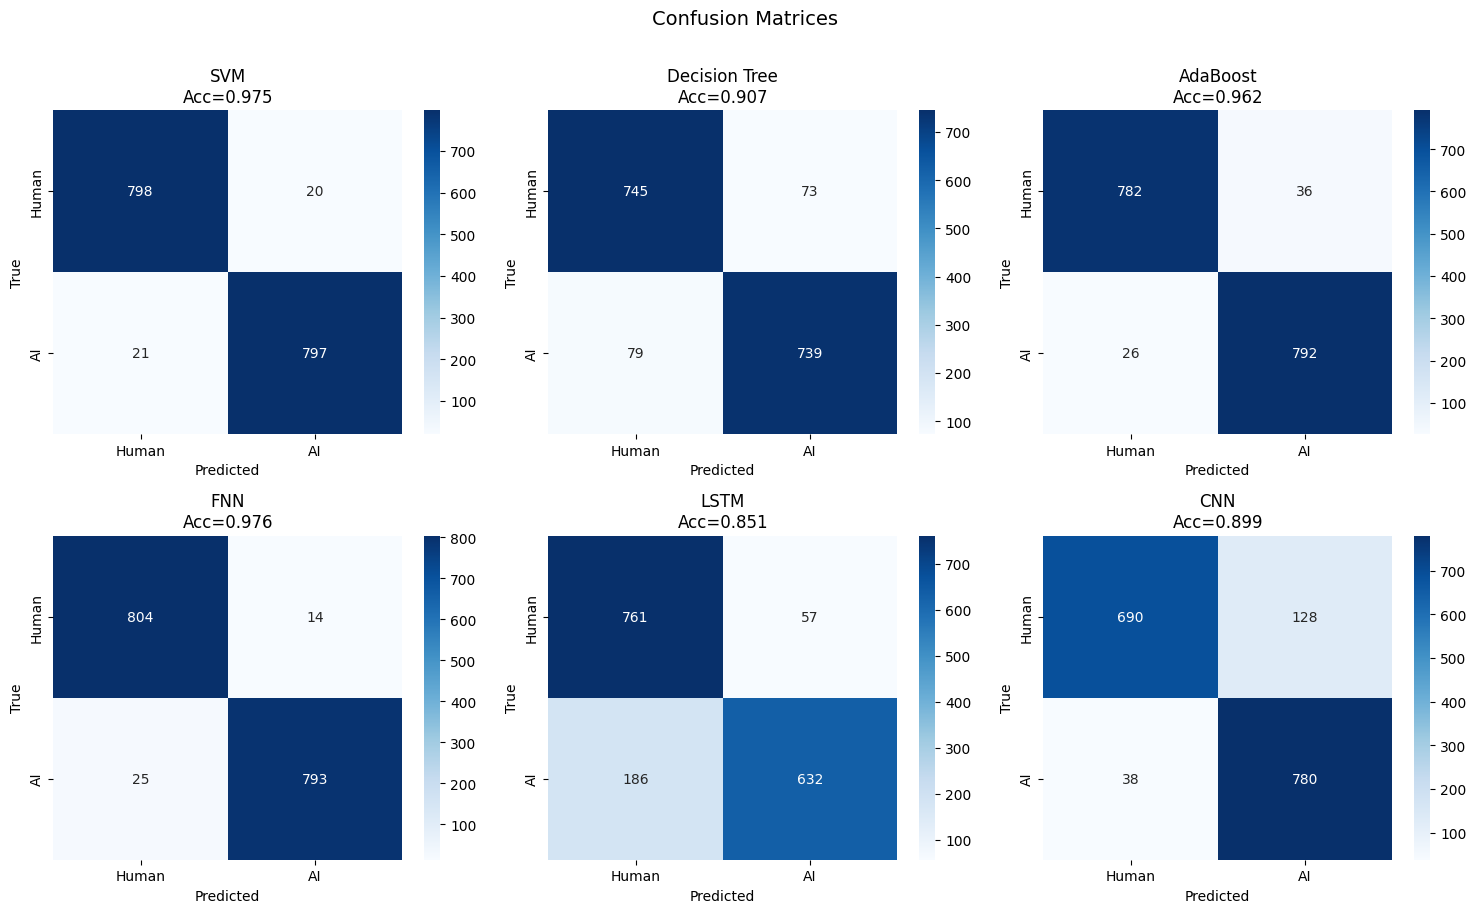

In [ ]:
# Confusion matrices
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
    ax.set_title(f'{name}\nAcc={r["acc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

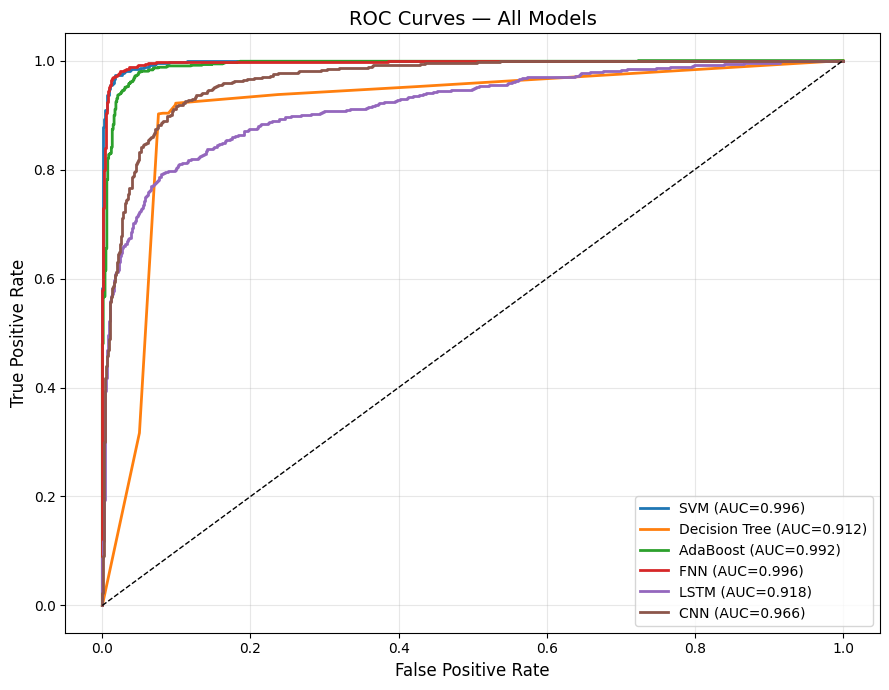

In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.tab10.colors

for (name, r), color in zip(results.items(), colors):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2,
            label=f"{name} (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=120)
plt.show()

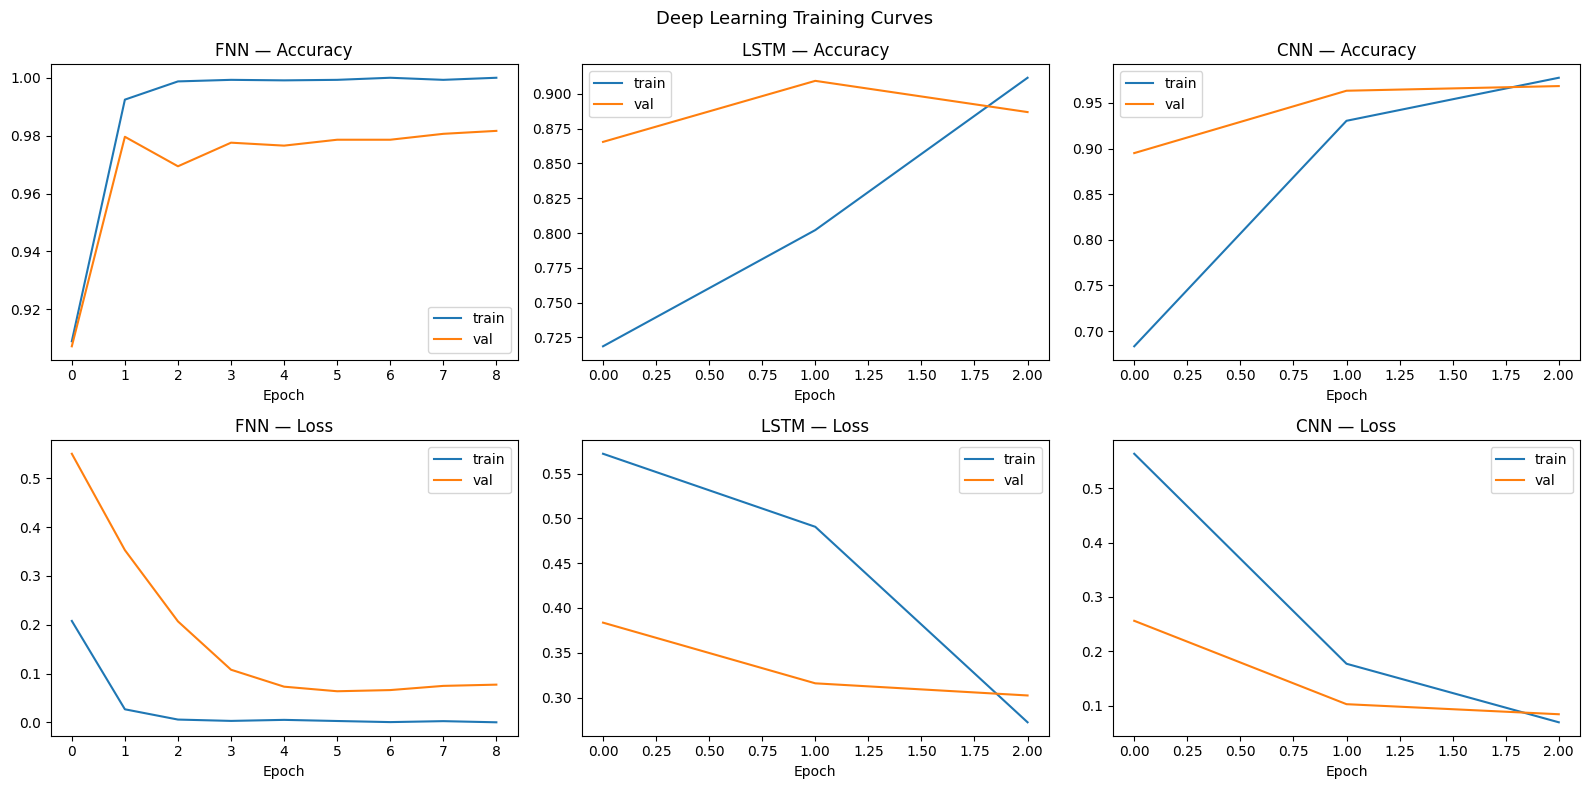

In [ ]:
# Training history — Deep Learning models
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (hist, name) in enumerate([
    (history_fnn, 'FNN'), (history_lstm, 'LSTM'), (history_cnn, 'CNN')
]):
    axes[0, col].plot(hist.history['accuracy'],     label='train')
    axes[0, col].plot(hist.history['val_accuracy'],  label='val')
    axes[0, col].set_title(f'{name} — Accuracy')
    axes[0, col].legend()
    axes[0, col].set_xlabel('Epoch')

    axes[1, col].plot(hist.history['loss'],     label='train')
    axes[1, col].plot(hist.history['val_loss'],  label='val')
    axes[1, col].set_title(f'{name} — Loss')
    axes[1, col].legend()
    axes[1, col].set_xlabel('Epoch')

plt.suptitle('Deep Learning Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('../data/training_curves.png', dpi=120)
plt.show()

In [ ]:
# SVM Feature Importance (Top TF-IDF weights)
if hasattr(best_svm, 'coef_'):
    coef = np.asarray(best_svm.coef_.todense()).flatten()
    feature_names = np.array(tfidf.get_feature_names_out())

    top_ai    = np.argsort(coef)[-20:][::-1]
    top_human = np.argsort(coef)[:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(feature_names[top_ai], coef[top_ai], color='tomato')
    axes[0].set_title('Top 20 AI-predictive features (SVM)')
    axes[1].barh(feature_names[top_human], coef[top_human], color='steelblue')
    axes[1].set_title('Top 20 Human-predictive features (SVM)')
    plt.tight_layout()
    plt.savefig('../data/svm_feature_importance.png', dpi=120)
    plt.show()
else:
    print('SVM with RBF kernel — feature importance not directly available.')

In [ ]:
# Decision Tree Feature Importance
importances = best_dt.feature_importances_
feature_names = np.array(tfidf.get_feature_names_out())
top20_idx = np.argsort(importances)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(20), importances[top20_idx], color='mediumseagreen')
ax.set_xticks(range(20))
ax.set_xticklabels(feature_names[top20_idx], rotation=45, ha='right')
ax.set_title('Decision Tree — Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('../data/dt_feature_importance.png', dpi=120)
plt.show()

In [ ]:
# Persist results for the Streamlit app
results_serialisable = {
    k: {kk: (vv.tolist() if hasattr(vv, 'tolist') else vv)
        for kk, vv in v.items()
        if kk not in ('y_pred', 'y_prob', 'fpr', 'tpr')}
    for k, v in results.items()
}
# Re-add list versions of arrays
for k, v in results.items():
    results_serialisable[k]['fpr'] = v['fpr'].tolist()
    results_serialisable[k]['tpr'] = v['tpr'].tolist()

json.dump(results_serialisable, open(f'{MODELS_DIR}/model_results.json', 'w'), indent=2)